In [8]:
import pandas as pd
import numpy as np
import torch

In [9]:
# Cell 3: ConditionalVAE (loss_function MODIFIED)
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Tuple

class ConditionalVAE(nn.Module):
    def __init__(self,
                 in_channels: int = 1,
                 loc_channels: int = 2,
                 mask_channels: int = 1,
                 latent_dim: int = 16,
                 hidden_dims: List[int] = [32, 64, 128, 256, 512],
                 img_size: int = 40):
        super().__init__()

        self.latent_dim = latent_dim
        self.img_size = img_size
        self.in_channels = in_channels
        self.loc_channels = loc_channels
        self.mask_channels = mask_channels

        # ---------------- Encoder ----------------
        enc_in_channels = in_channels + loc_channels + mask_channels
        self.hidden_dims_enc = hidden_dims
        modules = []
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(enc_in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU()
                )
            )
            enc_in_channels = h_dim
        self.encoder = nn.Sequential(*modules)

        # Compute encoder output sizes dynamically
        encoder_sizes = self.compute_encoder_sizes(img_size, hidden_dims)
        self.final_spatial = encoder_sizes[-1]
        flat_size = hidden_dims[-1] * self.final_spatial**2

        # Latent space
        self.fc_mu = nn.Linear(flat_size, latent_dim)
        self.fc_var = nn.Linear(flat_size, latent_dim)

        # ---------------- Decoder ----------------
        self.decoder_input = nn.Linear(
            latent_dim + (loc_channels + mask_channels) * img_size * img_size,
            flat_size
        )

        self.hidden_dims_dec = hidden_dims[::-1]

        dec_modules = []
        for i in range(len(self.hidden_dims_dec) - 1):
            dec_modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        self.hidden_dims_dec[i],
                        self.hidden_dims_dec[i+1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=0  # always 0, we will pad later
                    ),
                    nn.BatchNorm2d(self.hidden_dims_dec[i+1]),
                    nn.LeakyReLU()
                )
            )
        self.decoder = nn.Sequential(*dec_modules)

        self.final_mu = nn.Conv2d(self.hidden_dims_dec[-1], out_channels=in_channels, kernel_size=3, padding=1)
        self.final_logvar = nn.Conv2d(self.hidden_dims_dec[-1], out_channels=in_channels, kernel_size=3, padding=1)

    # ---------------- Static methods ----------------
    @staticmethod
    def compute_encoder_sizes(img_size, hidden_dims, kernel_size=3, stride=2, padding=1):
        sizes = []
        size = img_size
        for _ in hidden_dims:
            size = (size + 2*padding - kernel_size) // stride + 1
            sizes.append(size)
        return sizes

    # ---------------- Forward methods ----------------
    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        result = self.encoder(x)
        result = torch.flatten(result, start_dim=1)
        mu = self.fc_mu(result)
        log_var = self.fc_var(result)
        return mu, log_var

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps * std + mu

    def decode(self, z: torch.Tensor, loc_mask: torch.Tensor, meas_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # Combine conditioning info
        cond = torch.cat([loc_mask, meas_mask], dim=1)
        cond_flat = cond.view(cond.size(0), -1)
        dec_input = torch.cat([z, cond_flat], dim=1)

        result = self.decoder_input(dec_input)
        result = result.view(-1, self.hidden_dims_dec[0], self.final_spatial, self.final_spatial)
        result = self.decoder(result)

        # Zero-pad to ensure output is img_size x img_size
        _, _, h, w = result.shape
        pad_h = self.img_size - h
        pad_w = self.img_size - w
        if pad_h > 0 or pad_w > 0:
            # pad = (left, right, top, bottom)
            result = F.pad(result, (0, pad_w, 0, pad_h))

        mu_pred = self.final_mu(result)
        logvar_pred = torch.clamp(self.final_logvar(result), -10, 10)
        return mu_pred, logvar_pred

    def forward(self, x: torch.Tensor, loc_mask: torch.Tensor, meas_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        # Tile location mask if needed
        if loc_mask.dim() == 3:
            loc_mask = loc_mask.unsqueeze(0).repeat(x.size(0), 1, 1, 1)

        enc_in = torch.cat([x, loc_mask, meas_mask], dim=1)
        mu, log_var = self.encode(enc_in)
        z = self.reparameterize(mu, log_var)
        mu_pred, logvar_pred = self.decode(z, loc_mask, meas_mask)
        return mu_pred, logvar_pred, mu, log_var

    # ---------------- Loss function ----------------
    # --- MODIFIED to accept valid_mask ---
    def loss_function(self, x: torch.Tensor, mu_pred: torch.Tensor, logvar_pred: torch.Tensor,
                      mu: torch.Tensor, log_var: torch.Tensor, valid_mask: torch.Tensor, 
                      kld_weight: float = 1e-3) -> dict:
        
        const = torch.log(torch.tensor(2.0 * torch.pi, device=x.device))
        recon_var = torch.exp(logvar_pred)
        nll_element = 0.5 * ((x - mu_pred)**2 / recon_var + logvar_pred + const)

        # --- MODIFICATION: Apply valid_mask ---
        # valid_mask is [1, 1, H, W], nll_element is [B, 1, H, W]
        # Broadcasting will apply the mask to every sample in the batch
        nll_element_masked = nll_element * valid_mask
        
        # Get total NLL sum over all valid pixels in the batch
        total_nll_sum = torch.sum(nll_element_masked)
        
        # Get total number of valid pixels in the batch
        num_valid_per_sample = torch.sum(valid_mask)
        batch_size = x.size(0)
        total_valid_count = num_valid_per_sample * batch_size

        # Calculate mean NLL, handling potential division by zero
        if total_valid_count > 0:
            nll_loss = total_nll_sum / total_valid_count
        else:
            # If no valid pixels, set NLL loss to 0
            nll_loss = torch.tensor(0.0, device=x.device, requires_grad=True)
        # --- End MODIFICATION ---

        kld_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1))
        total_loss = nll_loss + kld_weight * kld_loss
        return {"loss": total_loss, "NLL": nll_loss, "KLD": kld_loss}

In [11]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim import Adam
from tqdm import tqdm

# -----------------------------
# 1️⃣ Load CSVs
# -----------------------------
df_coords = pd.read_csv("original_1600_grid_points.csv")
df_valid = pd.read_csv("inside.csv", header=None, names=['X','Y'])
df_measurements = pd.read_csv("combined_sinr.csv")  # 30 × 7700

H, W = 40, 40

# -----------------------------
# 2️⃣ Coordinates → Grid Indices
# -----------------------------
def coords_to_indices(df, H, W):
    x_vals = df['X'].values
    y_vals = df['Y'].values

    x_norm = (x_vals - x_vals.min()) / (x_vals.max() - x_vals.min())
    y_norm = (y_vals - y_vals.min()) / (y_vals.max() - y_vals.min())

    x_idx = np.clip((x_norm * (W-1)).astype(int), 0, W-1)
    y_idx = np.clip((y_norm * (H-1)).astype(int), 0, H-1)

    return np.stack([y_idx, x_idx], axis=1)

# Valid region mask
valid_indices = coords_to_indices(df_valid, H, W)

# Sensor measurement points (30 sensors)
measurement_indices = coords_to_indices(df_measurements[['X','Y']], H, W)
measurement_indices = np.array(measurement_indices)

# -----------------------------
# 3️⃣ Create Valid Mask
# -----------------------------
valid_mask = torch.zeros((H, W), dtype=torch.bool)
valid_mask[valid_indices[:,0], valid_indices[:,1]] = True
valid_coords_mask = valid_mask.unsqueeze(0).unsqueeze(0).float()  # (1,1,H,W)

# -----------------------------
# 4️⃣ Extract SINR samples (30 × 7700)
# -----------------------------
data_array = df_measurements.iloc[:, 2:].values.astype(np.float32)
num_sensors, num_samples = data_array.shape

# -----------------------------
# 5️⃣ ⭐ STANDARDIZE (per sensor)
# -----------------------------
means = data_array.mean(axis=1, keepdims=True)
stds = data_array.std(axis=1, keepdims=True) + 1e-8

data_array_std = (data_array - means) / stds

# -----------------------------
# 6️⃣ Fill the (samples, 40, 40) grid
# -----------------------------
grid = np.zeros((num_samples, H, W), dtype=np.float32)

for idx, (r, c) in enumerate(measurement_indices):
    grid[:, r, c] = data_array_std[idx]

# Final X_data shape = (7700, 1, 40, 40)
X_data = torch.tensor(grid).unsqueeze(1).float()

print("Final X_data:", X_data.shape)

# -----------------------------
# 7️⃣ Validation coordinates
# -----------------------------
val_indices = [3, 6, 25, 12, 13, 17, 19, 21, 10, 2]

val_coords = measurement_indices[val_indices]
print("Validation coord grid positions:\n", val_coords)

val_coords_y = torch.tensor(val_coords[:, 0], dtype=torch.long)
val_coords_x = torch.tensor(val_coords[:, 1], dtype=torch.long)

# train coordinates = all except val set
train_mask = np.ones(len(measurement_indices), dtype=bool)
train_coords = measurement_indices[train_mask]

train_coords_y = torch.tensor(train_coords[:, 0], dtype=torch.long)
train_coords_x = torch.tensor(train_coords[:, 1], dtype=torch.long)

num_train_locs = len(train_coords)
print("Train sensors:", num_train_locs)


Final X_data: torch.Size([7749, 1, 40, 40])
Validation coord grid positions:
 [[15  5]
 [29  7]
 [28 28]
 [14 12]
 [39 12]
 [14 19]
 [39 21]
 [20 23]
 [ 0 12]
 [13  3]]
Train sensors: 30


In [12]:
dataset = TensorDataset(X_data)

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=8, shuffle=False)


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConditionalVAE(
    in_channels=1,
    loc_channels=2,
    mask_channels=1,
    latent_dim=16,
    img_size=H,
    hidden_dims=[32,64,128,256,512]
).to(device)

optimizer = Adam(model.parameters(), lr=1e-3)
epochs = 50


In [14]:
# Build loc_mask_base (H × W × 2)
yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")

loc_x = (xx.float() / (W-1)).unsqueeze(0)  # (1,H,W)
loc_y = (yy.float() / (H-1)).unsqueeze(0)  # (1,H,W)

loc_mask_base = torch.cat([loc_x, loc_y], dim=0).unsqueeze(0)  # (1,2,H,W)


In [16]:
k_choices = torch.tensor([10, 15, 20, 25]).to(device)
k_probs   = torch.tensor([0.6, 0.133, 0.133, 0.133]).to(device)


In [18]:
def get_beta(epoch, max_epochs, warmup_epochs=10, final_beta=1.0):
    if epoch < warmup_epochs:
        return 0.0
    progress = (epoch - warmup_epochs) / (max_epochs - warmup_epochs)
    return min(final_beta, final_beta * progress)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    beta = get_beta(epoch, epochs)

    for (x_batch,) in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        x_batch = x_batch.to(device)
        B = x_batch.size(0)

        # 1. LOC mask
        loc_batch = loc_mask_base.repeat(B, 1, 1, 1)

        # 2. Random K sensors
        mask_batch = torch.zeros(B, 1, H, W, device=device)

        k_idx = torch.multinomial(k_probs, num_samples=B, replacement=True)
        k_vals = k_choices[k_idx]

        for i in range(B):
            k = k_vals[i].item()
            idx = torch.randperm(num_train_locs, device=device)[:k]
            y = train_coords_y[idx]
            x = train_coords_x[idx]
            mask_batch[i, 0, y, x] = 1.0

        # 3. Mask encoder input
        x_input = x_batch * mask_batch

        optimizer.zero_grad()

        mu_pred, logvar_pred, mu, log_var = model(x_input, loc_batch, mask_batch)

        losses = model.loss_function(
            x_batch, mu_pred, logvar_pred, mu, log_var,
            valid_mask=valid_coords_mask,
            kld_weight=beta
        )
        
        loss = losses["loss"]
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * B

    # ----------------------
    # VALIDATION
    # ----------------------
    model.eval()
    val_loss = 0.0

    # fixed 10-sensor mask
    val_mask = torch.zeros(1,1,H,W, device=device)
    val_mask[0,0,val_coords_y, val_coords_x] = 1.0

    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            B = x_batch.size(0)

            loc_batch = loc_mask_base.repeat(B, 1, 1, 1)
            mask_batch = val_mask.repeat(B, 1, 1, 1)

            x_input = x_batch * mask_batch

            mu_pred, logvar_pred, mu, log_var = model(x_input, loc_batch, mask_batch)

            losses = model.loss_function(
                x_batch, mu_pred, logvar_pred, mu, log_var,
                valid_mask=valid_coords_mask,
                kld_weight=1e-3
            )

            val_loss += losses["loss"].item() * B

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}] | Train {train_loss:.4f} | Val {val_loss:.4f}")

print("Training complete!")


Epoch [1/50] | Train -0.0931 | Val 4.3557


Epoch [2/50] | Train -0.8817 | Val 8.8779


Epoch [3/50] | Train -1.1232 | Val 9.4384


Epoch [4/50] | Train -1.3332 | Val 7.7900


Epoch [5/50] | Train -1.5266 | Val 10.9129


...

Epoch [46/50] | Train -1.7638 | Val -1.7603


Epoch [47/50] | Train -1.7646 | Val -1.7603


Epoch [48/50] | Train -1.7646 | Val -1.7604


Epoch [49/50] | Train -1.7642 | Val -1.7601


Epoch [50/50] | Train -1.7645 | Val -1.7602
Training complete!


x_input shape: torch.Size([8, 1, 40, 40])
Number of observed points per sample: 10.0


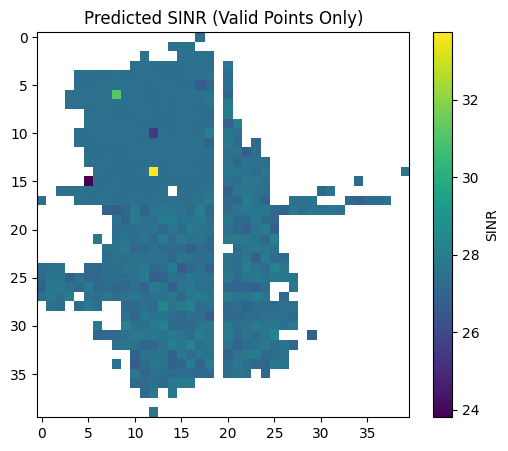

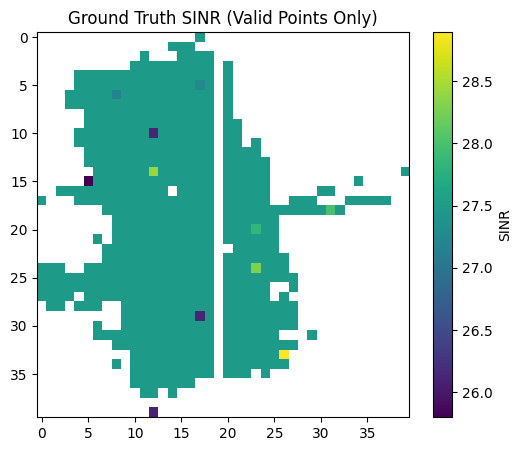

In [40]:
import torch

# Assume:
# val_loader -> your DataLoader for validation set
# val_mask -> tensor (H,W) with 1s at validation sensor locations
# device -> torch.device("cuda" or "cpu")

# Take one batch (or sample) from val_loader
x_batch, = next(iter(val_loader))  # x_batch: (B,1,H,W)
x_batch = x_batch.to(device)
# x_batch: (B,1,H,W)
B, _, H, W = x_batch.shape

B = x_batch.size(0)  # batch size from DataLoader

# Expand val_mask along batch dimension
mask_batch = val_mask.expand(B, -1, -1, -1).to(device)  # shape (B,1,H,W)

# Create masked input: zeros everywhere except val points
x_input = x_batch * mask_batch

print("x_input shape:", x_input.shape)
print("Number of observed points per sample:", mask_batch[0].sum().item())


# --- Forward pass ---
model.eval()
with torch.no_grad():
    mu_pred, logvar_pred, _, _ = model(
        x_input, 
        loc_mask_base.repeat(B,1,1,1), 
        mask_batch
    )
    # Sample from predicted Gaussian
    std_pred = torch.exp(0.5 * logvar_pred)
    sampled_pred = mu_pred + std_pred * torch.randn_like(std_pred)

# --- Build full prediction grid for all 650 valid points ---
# Compute single mean and std from the 30 measurement points
train_vals = []
for y,x in measurement_indices:  # 30 training points
    train_vals.append(grid_tensor[:, y, x])
train_vals = torch.stack(train_vals, dim=1)  # shape: (num_samples, 30)

means_scalar = train_vals.mean()  # single scalar
stds_scalar  = train_vals.std()   # single scalar

pred_grid_orig = torch.zeros((H,W))  # initialize zeros
gt_grid_orig   = x_batch[0,0].cpu() * stds_scalar + means_scalar

# Only fill the 650 valid points
valid_y, valid_x = valid_mask.nonzero(as_tuple=True)
pred_vals_orig = sampled_pred[0,0,valid_y, valid_x].cpu() * stds_scalar + means_scalar
pred_grid_orig[valid_y, valid_x] = pred_vals_orig

# ... (Previous code for Forward pass and pred_grid_orig remains the same) ...

# --- Build Ground Truth grid for only valid points ---
# 1. Initialize a grid of zeros (same size as H,W)
gt_grid_valid_only = torch.zeros((H, W))

# 2. Extract GT values at valid indices and un-normalize
# Note: We use valid_y, valid_x which you already computed from valid_mask
gt_vals = x_batch[0, 0, valid_y, valid_x].cpu() * stds_scalar + means_scalar

# 3. Fill the zero-grid only at those locations
gt_grid_valid_only[valid_y, valid_x] = gt_vals

# --- Visualization ---
import matplotlib.pyplot as plt
import numpy as np

# Plot Prediction
masked_pred = np.ma.masked_where(pred_grid_orig == 0, pred_grid_orig)
plt.figure(figsize=(6, 5))
plt.imshow(masked_pred, cmap='viridis', aspect='auto')
plt.colorbar(label='SINR')
plt.title("Predicted SINR (Valid Points Only)")
plt.show()

# Plot Ground Truth
# Mask the zeros so they show as background (white/purple depending on style)
masked_gt = np.ma.masked_where(gt_grid_valid_only == 0, gt_grid_valid_only)

plt.figure(figsize=(6, 5))
plt.imshow(masked_gt, cmap='viridis', aspect='auto')
plt.colorbar(label='SINR')
plt.title("Ground Truth SINR (Valid Points Only)")
plt.show()
